# setup

In [38]:
import network

import torch
import torch.nn as nn
import torch.nn.functional as F

# Unlike object, with SimpleNamespace you can add and remove attributes.
from types import SimpleNamespace 

import numpy as np

import random

# set the network size, to feed into the 1-layer network class

In [39]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

m = 50
n = 100

# Set seed
seed = 1
network.set_random_mode(True, seed)

init_parameters = SimpleNamespace()
init_parameters.m = m # input dimension
init_parameters.n = n # measurement dimension
init_parameters.seed = seed

# the measurement matrix: randomly initialized
init_parameters.W = torch.randn(n,m).to(device)/torch.sqrt(torch.tensor(n))

store_image = True

[Random Mode] Deterministic with seed 1


## save the parameters

In [40]:
import pickle
import os


weight_folder = f'weights/m_{m}_n_{n}_s_{seed}'
os.makedirs(weight_folder, exist_ok=True)

param_path = f'{weight_folder}/init_params.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(init_parameters, f)

# create the network

In [41]:
enose_network = network.enose(init_parameters)
print(enose_network.m)

50


## print the architecture of the network

In [42]:
for name, param in enose_network.named_parameters():
    print(f"{name}: {param.shape}")

fc1.weight: torch.Size([1, 100])
fc1.bias: torch.Size([1])


# create the dataset and creating a bi-directional dataset (NEW: 05/27)

In [ ]:
num_data=10000
training_frac=0.8
threshold=0.1
x_hat = threshold
num_training = int(num_data*training_frac)

# NEW (05/27/2025): allowing for bidirectional and custom data intervals
bidir_lower_bound = -1
bidir_upper_bound = 1

dataset = network.generate_custom_dataset(m, n, device, num_data, training_frac, threshold, bidir_lower_bound, bidir_upper_bound)

# training dataset
train_conc = dataset.train_conc
train_labels = dataset.train_labels

# test dataset
test_conc = dataset.test_conc
test_labels = dataset.test_labels

test_batch_size = 20

# initial accuracy
initial_accuracy = network.evaluate_random_batch(enose_network, dataset, test_batch_size=20, threshold=0.5)
print(initial_accuracy)

0.800000011920929


# optimize the parameters using cross entropy

In [ ]:
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(enose_network.parameters(), lr = 0.001)
lr=0.001

batch_size = 10 # having a small batch_size helps the model generalize to real life relationship (flat minimizer) --> maybe try 16?

steps = 10000
loss_vec = torch.zeros(steps)

test_interval = 50 # to make sure that all the test data are used multiple times
print_interval = 50 # how often to print the accuracies and loss in terminal
test_batch_size = 20 
accuracy_vec = torch.zeros(steps // test_interval)

loss_vec, accuracy_vec = network.train_model(
    enose_network,
    criterion,
    optimizer,
    lr,
    train_conc,
    train_labels,
    test_conc,
    test_labels,
    num_data,
    num_training,
    steps,
    batch_size,
    test_interval,
    print_interval,
    test_batch_size,
    device
)
                

[Step 0] Accuracy: 0.9500 | Train Loss: 0.6646
[Step 50] Accuracy: 0.9000 | Train Loss: 0.3930
[Step 100] Accuracy: 1.0000 | Train Loss: 0.8088
[Step 150] Accuracy: 0.8000 | Train Loss: 0.1144
[Step 200] Accuracy: 0.8500 | Train Loss: 0.1283
[Step 250] Accuracy: 0.7500 | Train Loss: 0.3199
[Step 300] Accuracy: 0.9000 | Train Loss: 0.3683
[Step 350] Accuracy: 0.9500 | Train Loss: 0.1072
[Step 400] Accuracy: 0.8500 | Train Loss: 0.9447
[Step 450] Accuracy: 0.8500 | Train Loss: 0.3263
[Step 500] Accuracy: 0.8500 | Train Loss: 0.3245
[Step 550] Accuracy: 0.9500 | Train Loss: 0.8087
[Step 600] Accuracy: 0.9500 | Train Loss: 0.6215
[Step 650] Accuracy: 0.9000 | Train Loss: 0.3329
[Step 700] Accuracy: 0.9500 | Train Loss: 0.1211
[Step 750] Accuracy: 0.9500 | Train Loss: 0.2784
[Step 800] Accuracy: 0.9500 | Train Loss: 0.0851
[Step 850] Accuracy: 0.8000 | Train Loss: 0.4559
[Step 900] Accuracy: 0.8500 | Train Loss: 0.0995
[Step 950] Accuracy: 0.9500 | Train Loss: 0.4036
[Step 1000] Accuracy: 0

## save the trained parameters

In [45]:
# to save the model weights
torch.save(enose_network.state_dict(), f"{weight_folder}/model_weights.pth")

In [46]:
accuracy_vec

tensor([0.9500, 0.9000, 1.0000, 0.8000, 0.8500, 0.7500, 0.9000, 0.9500, 0.8500,
        0.8500, 0.8500, 0.9500, 0.9500, 0.9000, 0.9500, 0.9500, 0.9500, 0.8000,
        0.8500, 0.9500, 0.8500, 0.9000, 0.8000, 0.9000, 0.9000, 0.7500, 0.9000,
        0.9000, 0.9000, 1.0000, 0.9000, 0.9000, 1.0000, 0.9000, 0.8500, 0.9000,
        0.9500, 0.9000, 0.9500, 0.9000, 1.0000, 0.8500, 0.9000, 1.0000, 0.8500,
        1.0000, 0.9000, 0.9500, 0.9500, 0.9000, 0.9500, 0.9000, 0.8500, 0.8500,
        1.0000, 0.7000, 0.8500, 0.8500, 0.9000, 0.9000, 0.9000, 0.9500, 0.9000,
        0.9000, 0.8000, 1.0000, 0.9000, 0.9500, 0.9000, 1.0000, 0.9500, 0.8000,
        0.9000, 0.9500, 0.9000, 0.9500, 0.9000, 0.9500, 0.8500, 0.8000, 0.9000,
        0.9000, 0.9500, 0.9500, 0.9500, 0.9000, 0.9500, 0.9500, 0.9500, 0.9000,
        0.9000, 0.9500, 0.9000, 1.0000, 1.0000, 0.9000, 1.0000, 0.8000, 0.9500,
        0.9500, 1.0000, 0.7000, 0.8500, 1.0000, 0.9000, 0.9000, 0.9500, 0.9500,
        0.9000, 1.0000, 0.9000, 0.9000, 

## save mean accuracy, to compare with the accuracy after weight pertubation

In [22]:
num_step = len(accuracy_vec)
mean_accuracy = torch.mean(accuracy_vec[num_step//2:-1])

param_path = f'{weight_folder}/mean_accuracy.pkl'
with open(param_path, 'wb') as f:
    pickle.dump(mean_accuracy, f)
    
print(num_step)
mean_accuracy

200


tensor(0.9722)

# plot the training loss and test accuracy

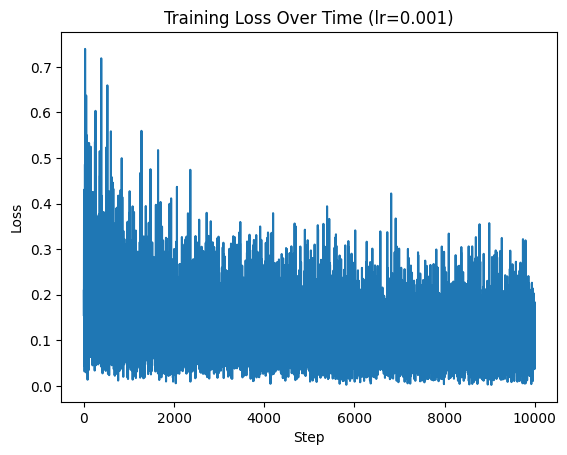

In [23]:
# Plot the loss curve and save (optional)

import matplotlib.pyplot as plt
import os

plt.plot(loss_vec)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Over Time (lr=" + str(lr) + ")")
# Make sure the folder exists
if store_image:
    folder = f'figures/m_{m}_n_{n}_s_{seed}'
    os.makedirs(folder, exist_ok=True)
    plt.savefig(f"{folder}/loss.pdf") 
plt.show()

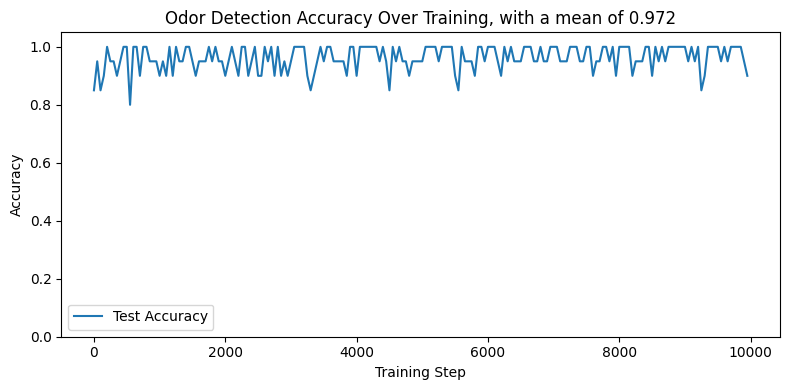

In [24]:
# Plot the test accuracy curve

import matplotlib.pyplot as plt

# mean_accuracy = torch.mean()

plt.figure(figsize=(8, 4))
plt.plot(torch.arange(0, steps, 50), accuracy_vec, label='Test Accuracy')
plt.xlabel("Training Step")
plt.ylabel("Accuracy")
plt.title(f"Odor Detection Accuracy Over Training, with a mean of {mean_accuracy:.3f}")
plt.ylim(0, 1.05)
# plt.grid(True)
plt.legend()
plt.tight_layout()
if store_image:
    plt.savefig(f"{folder}/accuracy.pdf")

plt.show()

# plot the weight matrices

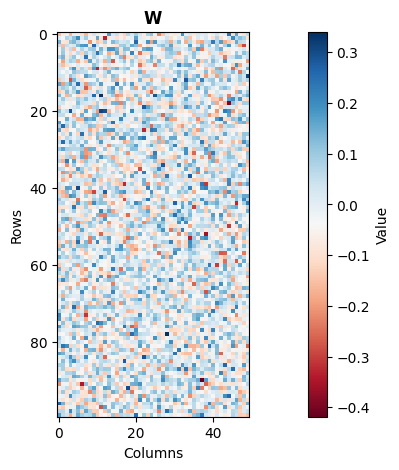

In [25]:
import torch
import matplotlib.pyplot as plt
W = enose_network.W.cpu().numpy()
# Plot using imshow
plt.figure(figsize=(15, 5))
plt.imshow(W, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W.pdf", bbox_inches='tight')
plt.show()

## plot the matrices

In [26]:
enose_network.fc1.bias

Parameter containing:
tensor([-0.8177], device='mps:0', requires_grad=True)

1
0.09541642630468151


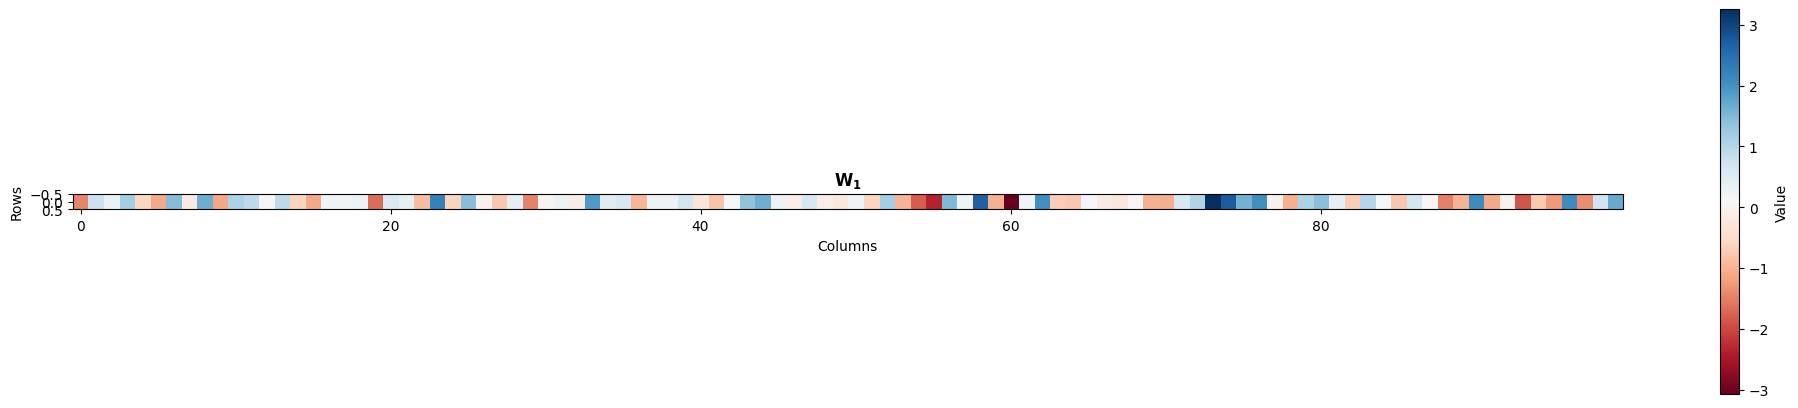

In [27]:
import torch
import matplotlib.pyplot as plt

W1 = enose_network.fc1.weight.detach().cpu().numpy()
b1 = enose_network.fc1.bias.detach().cpu().numpy()
print(b1.size)

W_h = W1 @ W
x1_hat_dagger = -b1[0]/W_h[0,0].item()
print(x1_hat_dagger)

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W1, cmap='RdBu', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W1.pdf", bbox_inches='tight')
plt.show()

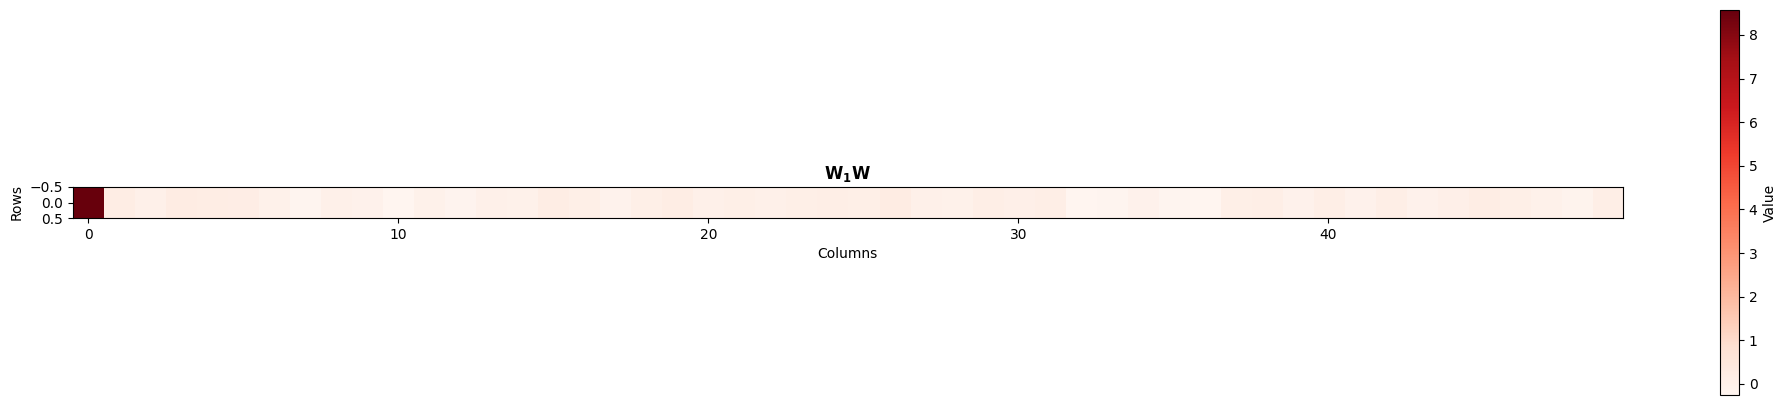

[ 8.57014275e+00  1.88675508e-01  3.32775016e-05  2.05678448e-01
  1.77742988e-01  1.39057279e-01 -3.19330096e-02 -2.13364258e-01
  1.95731279e-02 -6.18935525e-02 -2.38153726e-01 -1.55815007e-02
 -1.56717241e-01 -7.90829305e-03 -2.92416010e-02  1.88489303e-01
  6.05465956e-02 -8.70567188e-02  5.88895455e-02  1.87433541e-01
  5.46936551e-03  5.66487163e-02 -8.16787593e-03  7.25566223e-02
  1.14560761e-01  6.20330051e-02  1.95490360e-01  5.18601434e-03
 -4.41298820e-02  1.04524694e-01  2.98778396e-02  1.03292637e-01
 -2.54517406e-01 -2.09082514e-01 -7.24388435e-02 -1.89861104e-01
 -2.52047002e-01  6.53951615e-02  1.19366199e-01 -5.00354245e-02
  9.51389894e-02 -6.19123951e-02  1.01583831e-01 -5.42150363e-02
  3.47447433e-02  1.65676117e-01  8.81820321e-02 -3.12562659e-02
 -1.17859021e-01  1.17369071e-01]


In [28]:
import torch
import matplotlib.pyplot as plt

# Plot using imshow
plt.figure(figsize=(25, 5))
plt.imshow(W_h , cmap='Reds', interpolation='nearest')
plt.colorbar(label='Value')
plt.title(r'$\bf W_1 W$')
plt.xlabel('Columns')
plt.ylabel('Rows')
if store_image:
    plt.savefig(f"{folder}/W_h.pdf")
# plt.savefig("figures/W_h.pdf")
plt.show()
plt.close()

# to verify that the first element dominates
print(W_h[0]) 

# plot the simplified 1-D curve, since the first element dominates

In [29]:
x_hat = threshold
print(x_hat)
print(x1_hat_dagger)

0.1
0.09541642630468151


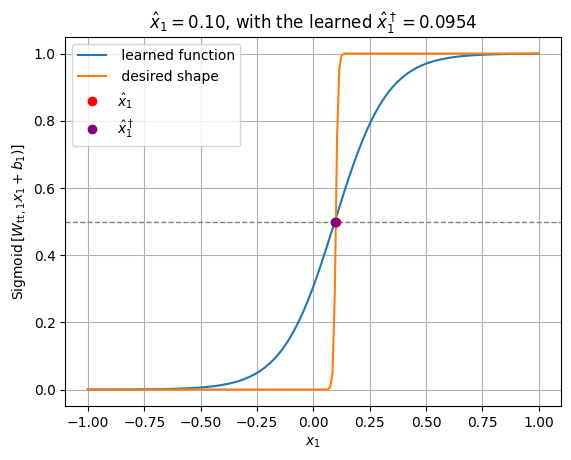

In [30]:
# x = torch.linspace(0, 1, 200)
x = torch.linspace(-1, 1, 200)

y = torch.sigmoid( W_h[0][0]*x + b1 )
y_2 = torch.sigmoid( 200*(x - x_hat) )
plt.plot(x, y, label =' learned function')
plt.plot(x, y_2, label = ' desired shape')
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1)
plt.plot(x_hat, 0.5, 'o', color='red', label=r'$\hat{x}_1$')
plt.plot(x1_hat_dagger, 0.5, 'o', color='purple', label=r'$\hat{x}_1^\dagger$')


plt.title(fr'$\hat{{x}}_1 = {x_hat:.2f} $, with the learned $\hat{{x}}_1^\dagger = {x1_hat_dagger:.4f} $')
plt.xlabel(r'$x_1$')
plt.ylabel(r'$\operatorname{Sigmoid}\left[ W_{\operatorname{tt},1} x_1 + b_1 ) \right]$')
plt.legend()
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/pickup_first_dim.pdf", bbox_inches='tight')
plt.show()

## verify that the analytical full expression is correct; compare the full expression versus the simplified 1-D expression

In [32]:
# the test dataset
test_idx = torch.randint(0, num_data - num_training, (test_batch_size,))
x_test = test_conc[:, test_idx]
y_test = test_labels[test_idx].view(-1, 1).float()

In [33]:
## ===== to check the analytical expression matches with the network expression =====

W_h_tensor = torch.tensor(W_h, dtype=torch.float32, device=x_test.device)
bias_final = torch.tensor(b1, dtype=torch.float32, device=x_test.device)

# the network expression
with torch.no_grad():
    enose_network.eval()
    pred = enose_network(x_test)
    predicted_labels = (pred > 0.5).float()
    accuracy = (predicted_labels == y_test).float().mean().item()
    # accuracy_vec[ steps // test_interval] = accuracy
    print(f"Test Accuracy = {accuracy:.4f}")

print(pred.mT)

# the analytical expression
out1 = torch.sigmoid(W_h_tensor @ x_test + bias_final)  # shape: [output_dim, num_samples]
out1 = out1[0]
print(out1)

Test Accuracy = 1.0000
tensor([[9.9840e-01, 9.7408e-01, 9.6046e-01, 9.9112e-01, 2.7049e-04, 5.4443e-04,
         9.9939e-01, 1.1617e-02, 9.2829e-01, 9.8718e-01, 7.6043e-04, 1.4188e-03,
         9.9055e-01, 7.9969e-02, 8.6465e-01, 1.5478e-03, 1.9457e-03, 5.2900e-03,
         9.8266e-01, 1.8786e-04]], device='mps:0')
tensor([9.9840e-01, 9.7408e-01, 9.6046e-01, 9.9112e-01, 2.7049e-04, 5.4443e-04,
        9.9939e-01, 1.1617e-02, 9.2829e-01, 9.8718e-01, 7.6043e-04, 1.4188e-03,
        9.9055e-01, 7.9969e-02, 8.6465e-01, 1.5478e-03, 1.9457e-03, 5.2901e-03,
        9.8266e-01, 1.8786e-04], device='mps:0')


In [34]:
out2 = torch.sigmoid(W_h_tensor[0][0] * x_test[0, :] + bias_final)  # shape: [num_samples]
out3 = torch.sigmoid(W_h_tensor[0][0] * (x_test[0, :] - x1_hat_dagger) )  # shape: [num_samples]
out4 = torch.sigmoid(W_h_tensor[0][0] * (x_test[0, :] - x_hat) )  # shape: [num_samples]

accr_1 = ((out1 > 0.5).float().T == y_test.squeeze()).float().mean().item()
accr_2 = ((out2 > 0.5).float().T == y_test.squeeze()).float().mean().item()

/var/folders/2w/xwcnb67d2wq2rf_47cyk6vpr0000gn/T/ipykernel_7475/4066574986.py:5: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3687.)
  accr_1 = ((out1 > 0.5).float().T == y_test.squeeze()).float().mean().item()


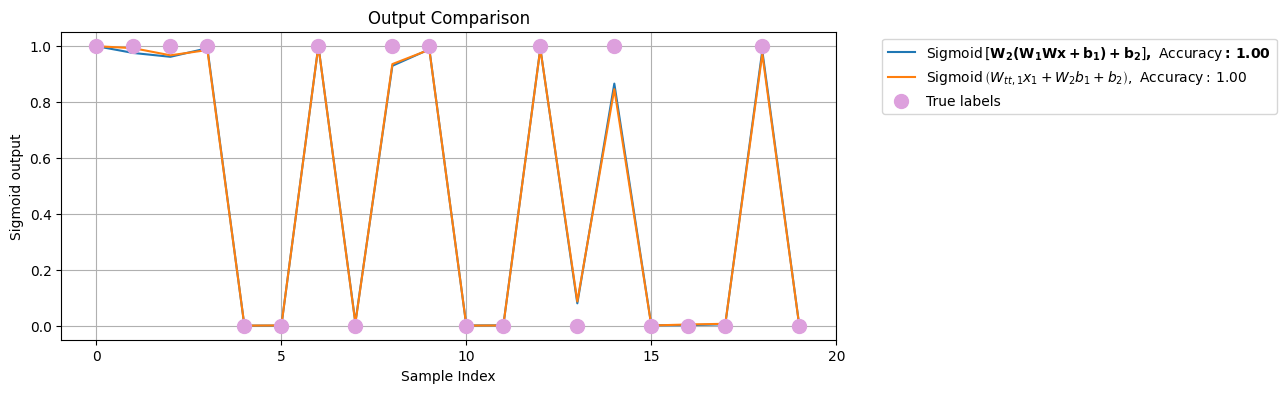

In [35]:
import torch
import matplotlib.pyplot as plt

# Plot comparison
plt.figure(figsize=(10, 4))
plt.plot(out1.cpu(), label=fr'$\operatorname{{Sigmoid}}\left[\bf W_2 (W_1 Wx +b_1)+b_2 \right],\ \operatorname{{Accuracy: }} {accr_1:.2f} $')
plt.plot(out2.cpu(), label=fr'$\operatorname{{Sigmoid}}\left(W_{{tt,1}} x_1 + W_2b_1+b_2 \right),\ \operatorname{{Accuracy: }} {accr_2:.2f} $')
# plt.plot(out3.cpu(), label=fr'$\operatorname{{Sigmoid}}\left[\bf W_2 (W_1 Wx +b_1)+b_2 \right],\ \operatorname{{Accuracy: }} {accr_1:.2f} $')
# plt.plot(out4.cpu(), label=fr'$\operatorname{{Sigmoid}}\left(W_{{tt,1}} x_1 + W_2b_1+b_2 \right),\ \operatorname{{Accuracy: }} {accr_2:.2f} $')
# plt.plot(log_out2.cpu(), label=r'$\operatorname{Sigmoid}$', linestyle='--')
plt.plot(y_test.cpu(), label = 'True labels', linestyle='none', marker='.', markersize = 20, color='plum')
plt.title("Output Comparison")
plt.xlabel("Sample Index")
plt.xticks(ticks=range(0, len(y_test)+1,5), labels=range(0, len(y_test)+1,5))
plt.ylabel("Sigmoid output")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
if store_image:
    plt.savefig(f"{folder}/Output_Comparison.pdf", bbox_inches='tight')
plt.show()